In [1]:
from pythermalcomfort.models import utci
import iertools.read as rd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
f = '../data/raw/epw/MEX_CAM_Campeche-Ongay.Intl.AP.766950_TMYx.2009-2023.epw'
# f = '../data/MEX_CAM_Campeche-Ongay.Intl.AP.766950_TMYx.2004-2018/MEX_CAM_Campeche-Ongay.Intl.AP.766950_TMYx.2004-2018.epw'
# f = '../data/MEX_CAM_Campeche-Ongay.Intl.AP.766950_TMYx.2007-2021/MEX_CAM_Campeche-Ongay.Intl.AP.766950_TMYx.2007-2021.epw'
CAMPECHE=  rd.read_epw(f, alias=True, year = 2021)

C:\Users\roele\venvs\alldays\Lib\site-packages\iertools\read.py:218: UserWarning: Year has been changed, be carefull
  warnings.warn("Year has been changed, be carefull")


In [3]:
CAMPECHE.columns

Index(['Data Source and Uncertainty Flags', 'To', 'Dew Point Temperature',
       'RH', 'P', 'Extraterrestrial Horizontal Radiation',
       'Extraterrestrial Direct Normal Radiation',
       'Horizontal Infrared Radiation Intensity', 'Ig', 'Ib', 'Id',
       'Global Horizontal Illuminance', 'Direct Normal Illuminance',
       'Diffuse Horizontal Illuminance', 'Zenith Luminance', 'Wd', 'Ws',
       'Total Sky Cover', 'Opaque Sky Cover', 'Visibility', 'Ceiling Height',
       'Present Weather Observation', 'Present Weather Codes',
       'Precipitable Water', 'Aerosol Optical Depth', 'Snow Depth',
       'Days Since Last Snowfall', 'Albedo', 'Liquid Precipitation Depth',
       'Liquid Precipitation Quantity'],
      dtype='object')

In [4]:
cols = ['To', 'Ws', 'RH']
CAMPECHE = CAMPECHE[cols]

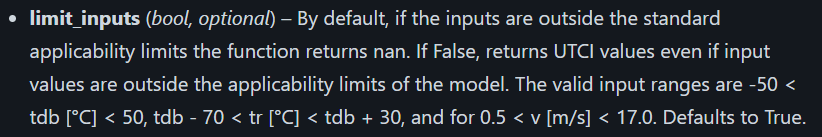

https://pythermalcomfort.readthedocs.io/en/latest/documentation/models.html#universal-thermal-climate-index-utci

In [5]:
CAMPECHE.loc[CAMPECHE["Ws"] < 0.5, "Ws"] = 0.5
# Los datos de viento se obtienen directamente del archivo meteorológico. En ausencia de viento, el valor se establece en 0,5 m/s, que es el valor mínimo permitido por el modelo UTCI.
# https://cbe-berkeley.gitbook.io/clima/documentation/tabs-explained/outdoor-comfort/utci-explained

In [6]:
def get_UTCI(row, t_col='To', ws_col='Ws', rh_col="RH"):
    # try:
    #     if pd.isna(row[t_col]) or pd.isna(row[ws_col]) or pd.isna(row[rh_col]):
    #         # print(f"Valores faltantes en fila {row.name}: T={row[t_col]}, WS={row[ws_col]}, RH={row[rh_col]}")
    #         return np.nan

        result = utci(
            tdb=row[t_col],
            tr=row[t_col],  # suponiendo igualdad con Te
# El cálculo de la " ganancia solar sobre las personas " determina la ganancia solar que recibe el cuerpo humano, es decir, 
# la temperatura radiante media. Para simular una situación sin sol, Clima considera a la persona rodeada de superficies que le
# dan sombra, todas las cuales tienden a alcanzar una temperatura de bulbo seco; 
# https://cbe-berkeley.gitbook.io/clima/documentation/tabs-explained/outdoor-comfort/utci-explained
            v=row[ws_col],
            rh=row[rh_col], 
            # limit_inputs = False
        )

        return result.utci

    # except Exception as e:
    #     # print(f"Error calculando UTCI para fila {row.name}: {str(e)}")
    #     return np.nan
    #  https://climate-adapt.eea.europa.eu/en/metadata/indicators/thermal-comfort-indices-universal-thermal-climate-index-1979-2019
        
def categorizar_utci(valor):
    if pd.isna(valor):
        return np.nan
    if valor > 46:
        return "calor_extremo"
    elif 38 < valor <= 46:
        return "calor_muy_fuerte"
    elif 32 < valor <= 38:
        return "calor_fuerte"
    elif 26 < valor <= 32:
        return "calor_moderado"
    elif 9 < valor <= 26:
        return "sin_estres_termico"
    elif 0 < valor <= 9:
        return "frio_ligero"
    elif -13 < valor <= 0:
        return "frio_moderado"
    elif -27 < valor <= -13:
        return "frio_fuerte"
    elif -40 < valor <= -27:
        return "frio_muy_fuerte"
    elif valor <= -40:
        return "frio_extremo"
    else:
        return "sin_categoria"

In [7]:
# Calcular UTCI y guardarlo en una nueva columna
CAMPECHE["UTCI"] = CAMPECHE.apply(get_UTCI, axis=1)

# Categorizar el UTCI en otra columna
CAMPECHE["UTCI_cat"] = CAMPECHE["UTCI"].apply(categorizar_utci)


In [8]:
CAMPECHE["UTCI_cat"].value_counts(dropna=False).sum()

np.int64(8760)

In [9]:
CAMPECHE["UTCI_cat"].value_counts(dropna=False)

UTCI_cat
sin_estres_termico    3842
calor_moderado        3783
calor_fuerte          1041
calor_muy_fuerte        87
frio_ligero              5
calor_extremo            2
Name: count, dtype: int64

In [10]:
cols = ['To', 'Ws', 'RH']

for col in cols:
    n_nan = CAMPECHE[col].isna().sum()
    print(f"{col}: {n_nan} valores NaN")

To: 0 valores NaN
Ws: 0 valores NaN
RH: 0 valores NaN


In [11]:
CAMPECHE

,To,Ws,RH,UTCI,UTCI_cat
tiempo,,,,,
2021-01-01 00:00:00,25.5,5.4,79,22.5,sin_estres_termico
2021-01-01 01:00:00,25.2,5.2,81,22.3,sin_estres_termico
2021-01-01 02:00:00,24.6,5.0,83,21.7,sin_estres_termico
2021-01-01 03:00:00,24.0,4.8,84,21.1,sin_estres_termico
2021-01-01 04:00:00,23.6,4.4,86,21.1,sin_estres_termico
...,...,...,...,...,...
2021-12-31 19:00:00,26.0,5.1,84,23.9,sin_estres_termico
2021-12-31 20:00:00,25.0,2.6,89,25.7,sin_estres_termico
2021-12-31 21:00:00,25.0,5.1,89,22.7,sin_estres_termico


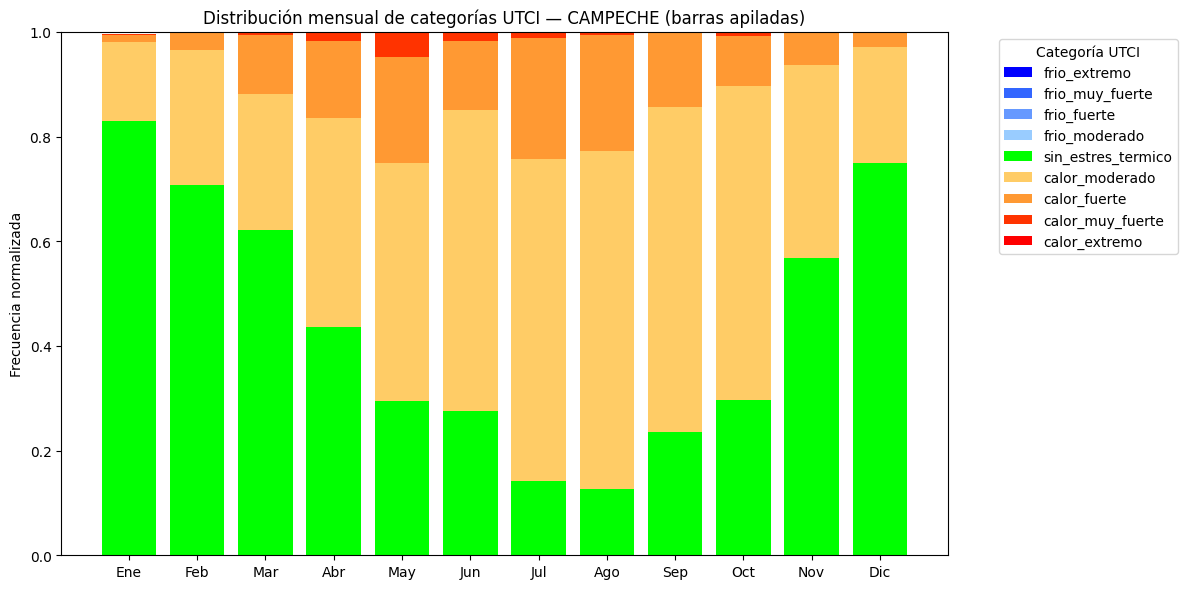

In [12]:
CAMPECHE.index = pd.to_datetime(CAMPECHE.index)

# Agregar columna de mes
CAMPECHE["mes"] = CAMPECHE.index.month

# Orden de categorías (normalizadas)
orden_categorias = [
    "frio_extremo", "frio_muy_fuerte", "frio_fuerte", "frio_moderado",
    "sin_estres_termico",
    "calor_moderado", "calor_fuerte", "calor_muy_fuerte", "calor_extremo"
]

# Colores asignados a cada categoría
colores = {
    "frio_extremo": "#0000FF",
    "frio_muy_fuerte": "#3366FF",
    "frio_fuerte": "#6699FF",
    "frio_moderado": "#99CCFF",
    "sin_estres_termico": "#00FF00",
    "calor_moderado": "#FFCC66",
    "calor_fuerte": "#FF9933",
    "calor_muy_fuerte": "#FF3300",
    "calor_extremo": "#FF0000"
}

# Crear un DataFrame: filas = meses, columnas = categorías
df_meses = pd.DataFrame(0.0, index=range(1, 13), columns=orden_categorias)

# Calcular las frecuencias normalizadas por mes
for mes in range(1, 13):
    df_mes = CAMPECHE[CAMPECHE["mes"] == mes]
    conteo = df_mes["UTCI_cat"].value_counts(normalize=True)
    df_meses.loc[mes] = conteo.reindex(orden_categorias).fillna(0)

# Crear la gráfica
plt.figure(figsize=(12,6))

bottom = [0] * 12  # acumulador para el apilado

for categoria in orden_categorias:
    valores = df_meses[categoria].values
    plt.bar(
        df_meses.index,
        valores,
        bottom=bottom,
        label=categoria,
        color=colores[categoria]
    )
    bottom = bottom + valores  # actualizar acumulador

plt.xticks(range(1,13), ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"])
plt.ylabel("Frecuencia normalizada")
plt.title("Distribución mensual de categorías UTCI — CAMPECHE (barras apiladas)")
plt.legend(title="Categoría UTCI", bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()

In [13]:
# Crear DataFrame vacío con dtype flotante
df_meses = pd.DataFrame(
    0.0,
    index=range(1, 13),
    columns=orden_categorias   # ← ahora son las categorías normalizadas
)

for mes in range(1, 13):

    df_mes = CAMPECHE[CAMPECHE["mes"] == mes]
    conteo = df_mes["UTCI_cat"].value_counts(normalize=True)

    df_meses.loc[mes] = conteo.reindex(orden_categorias).fillna(0).astype(float)

# Multiplicar por 100 si quieres porcentajes
df_meses_percent = df_meses * 100

# Agregar columnas de disconfort usando las nuevas categorías normalizadas
df_meses_percent["disc_calido"] = (
    df_meses_percent["calor_moderado"] +
    df_meses_percent["calor_fuerte"] +
    df_meses_percent["calor_muy_fuerte"] +
    df_meses_percent["calor_extremo"]
)

df_meses_percent["disc_frio"] = (
    df_meses_percent["frio_extremo"] +
    df_meses_percent["frio_muy_fuerte"] +
    df_meses_percent["frio_fuerte"] +
    df_meses_percent["frio_moderado"]
)

df_meses_percent["nombre_mes"] = df_meses_percent.index

df_meses_percent["nombre_mes"] = df_meses_percent["nombre_mes"].map({
    1:"Enero", 2:"Febrero", 3:"Marzo", 4:"Abril", 5:"Mayo", 6:"Junio",
    7:"Julio", 8:"Agosto", 9:"Septiembre", 10:"Octubre", 11:"Noviembre", 12:"Diciembre"
})

df_meses_percent = df_meses_percent.set_index("nombre_mes")
df_meses_percent

,frio_extremo,frio_muy_fuerte,frio_fuerte,frio_moderado,sin_estres_termico,calor_moderado,calor_fuerte,calor_muy_fuerte,calor_extremo,disc_calido,disc_frio
nombre_mes,,,,,,,,,,,
Enero,0.0,0.0,0.0,0.0,82.930108,15.188172,1.344086,0.134409,0.000000,16.666667,0.0
Febrero,0.0,0.0,0.0,0.0,70.684524,25.892857,3.273810,0.000000,0.000000,29.166667,0.0
Marzo,0.0,0.0,0.0,0.0,62.231183,25.940860,11.155914,0.672043,0.000000,37.768817,0.0
Abril,0.0,0.0,0.0,0.0,43.611111,40.000000,14.583333,1.805556,0.000000,56.388889,0.0
Mayo,0.0,0.0,0.0,0.0,29.435484,45.564516,20.161290,4.704301,0.134409,70.564516,0.0
Junio,0.0,0.0,0.0,0.0,27.500000,57.500000,13.194444,1.805556,0.000000,72.500000,0.0
Julio,0.0,0.0,0.0,0.0,14.112903,61.559140,23.118280,1.075269,0.134409,85.887097,0.0
Agosto,0.0,0.0,0.0,0.0,12.634409,64.650538,22.177419,0.537634,0.000000,87.365591,0.0
Septiembre,0.0,0.0,0.0,0.0,23.611111,62.083333,14.166667,0.138889,0.000000,76.388889,0.0


In [14]:
df_meses.columns

Index(['frio_extremo', 'frio_muy_fuerte', 'frio_fuerte', 'frio_moderado',
       'sin_estres_termico', 'calor_moderado', 'calor_fuerte',
       'calor_muy_fuerte', 'calor_extremo'],
      dtype='object')

In [15]:
CAMPECHE

,To,Ws,RH,UTCI,UTCI_cat,mes
tiempo,,,,,,
2021-01-01 00:00:00,25.5,5.4,79,22.5,sin_estres_termico,1
2021-01-01 01:00:00,25.2,5.2,81,22.3,sin_estres_termico,1
2021-01-01 02:00:00,24.6,5.0,83,21.7,sin_estres_termico,1
2021-01-01 03:00:00,24.0,4.8,84,21.1,sin_estres_termico,1
2021-01-01 04:00:00,23.6,4.4,86,21.1,sin_estres_termico,1
...,...,...,...,...,...,...
2021-12-31 19:00:00,26.0,5.1,84,23.9,sin_estres_termico,12
2021-12-31 20:00:00,25.0,2.6,89,25.7,sin_estres_termico,12
2021-12-31 21:00:00,25.0,5.1,89,22.7,sin_estres_termico,12


<Axes: xlabel='tiempo'>

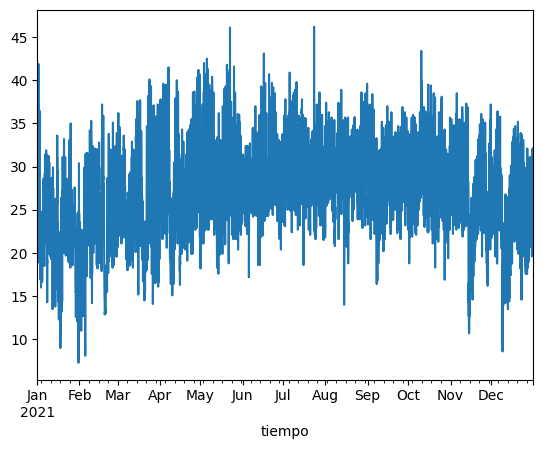

In [16]:
CAMPECHE['UTCI'].plot()

In [17]:
# Al tener los limites del UTCI activados, los NaN representan aquellos momentos en los que las condiciones revasaron los limites
CAMPECHE.isna().sum()

To          0
Ws          0
RH          0
UTCI        0
UTCI_cat    0
mes         0
dtype: int64

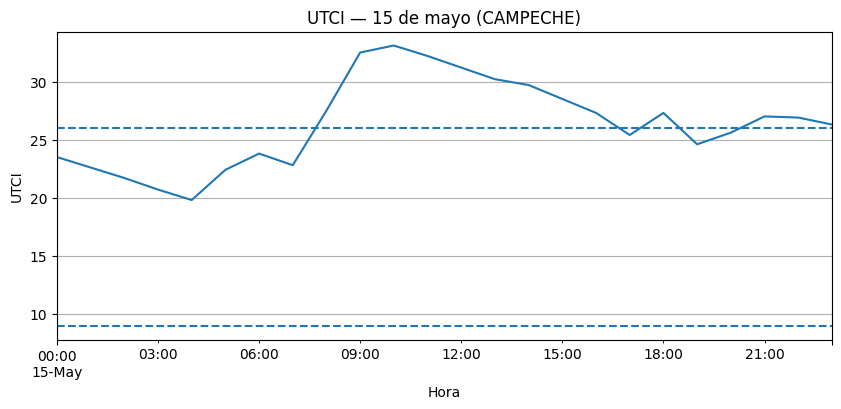

In [18]:
df_2enero = CAMPECHE.loc["2021-05-15"]

df_2enero["UTCI"].plot(figsize=(10,4))

# Líneas horizontales
plt.axhline(y=9, linestyle="--")
plt.axhline(y=26, linestyle="--")

plt.title("UTCI — 15 de mayo (CAMPECHE)")
plt.ylabel("UTCI")
plt.xlabel("Hora")
plt.grid(True)
plt.show()

In [19]:
def area_UTCI(row):
    if pd.isna(row['UTCI']):
        return np.nan
    elif row['UTCI'] < 9:
        return row['UTCI'] - 9
    elif 9 <= row['UTCI'] <= 26:
        return 0
    elif 26 < row['UTCI']:
        return row['UTCI'] - 26
    else:
        return np.nan  # Por si aparece un valor inesperado en 'bloque'

# Crear la nueva columna kWh_tri
CAMPECHE['area_UTCI'] = CAMPECHE.apply(area_UTCI, axis=1)
CAMPECHE

,To,Ws,RH,UTCI,UTCI_cat,mes,area_UTCI
tiempo,,,,,,,
2021-01-01 00:00:00,25.5,5.4,79,22.5,sin_estres_termico,1,0.0
2021-01-01 01:00:00,25.2,5.2,81,22.3,sin_estres_termico,1,0.0
2021-01-01 02:00:00,24.6,5.0,83,21.7,sin_estres_termico,1,0.0
2021-01-01 03:00:00,24.0,4.8,84,21.1,sin_estres_termico,1,0.0
2021-01-01 04:00:00,23.6,4.4,86,21.1,sin_estres_termico,1,0.0
...,...,...,...,...,...,...,...
2021-12-31 19:00:00,26.0,5.1,84,23.9,sin_estres_termico,12,0.0
2021-12-31 20:00:00,25.0,2.6,89,25.7,sin_estres_termico,12,0.0
2021-12-31 21:00:00,25.0,5.1,89,22.7,sin_estres_termico,12,0.0


In [20]:
area_calida = CAMPECHE["area_UTCI"][CAMPECHE["area_UTCI"] > 0].sum()
area_calida

np.float64(19518.6)

In [21]:
area_fria = CAMPECHE["area_UTCI"][CAMPECHE["area_UTCI"] < 0].sum()
area_fria

np.float64(-3.8000000000000016)

In [22]:
CAMPECHE["area_UTCI"][CAMPECHE["area_UTCI"] < 0]

tiempo
2021-01-31 07:00:00   -1.7
2021-01-31 08:00:00   -0.8
2021-02-05 06:00:00   -0.9
2021-12-09 07:00:00   -0.4
Name: area_UTCI, dtype: float64

In [31]:
CAMPECHE["nombre_mes"] = CAMPECHE.index.month

tabla_area = (
    CAMPECHE.loc[CAMPECHE["nombre_mes"].between(4, 9), ["nombre_mes", "area_UTCI"]]
    .assign(
        area_calida=lambda df: df["area_UTCI"].clip(lower=0),
        area_fria=lambda df: df["area_UTCI"].clip(upper=0)
    )
    .groupby("nombre_mes")[["area_calida", "area_fria"]]
    .sum()
    .reset_index()
)

tabla_area["nombre_mes"] = tabla_area["nombre_mes"].map({
    1:"Enero", 2:"Febrero", 3:"Marzo", 4:"Abril", 5:"Mayo", 6:"Junio",
    7:"Julio", 8:"Agosto", 9:"Septiembre", 10:"Octubre", 11:"Noviembre", 12:"Diciembre"
})


tabla_area = tabla_area.set_index("nombre_mes")

tabla_area

,area_calida,area_fria
nombre_mes,,
Abril,1838.6,0.0
Mayo,2736.2,0.0
Junio,1920.0,0.0
Julio,2672.6,0.0
Agosto,2744.3,0.0
Septiembre,1996.7,0.0


In [32]:
tabla_area = tabla_area.merge(df_meses_percent[["disc_calido","disc_frio"]], 
                     left_index=True, 
                     right_index=True)
tabla_area = tabla_area.rename(columns = {'disc_calido':'disc_calido_percent', 'disc_frio':"disc_frio_percent"})

In [33]:
tabla_area['subsidio_area_calida_percent'] = tabla_area['area_calida'] / tabla_area['area_calida'].sum() * 100
tabla_area['subsidio_area_fria_percent'] = tabla_area['area_fria'] / tabla_area['area_fria'].sum() * 100
tabla_area['subsidio_disc_calido_percent'] = tabla_area['disc_calido_percent'] / tabla_area['disc_calido_percent'].sum() * 100
tabla_area['subsidio_disc_frio_percent'] = tabla_area['disc_frio_percent'] / tabla_area['disc_frio_percent'].sum() * 100
tabla_area[['subsidio_disc_calido_percent', 'subsidio_area_calida_percent']]

,subsidio_disc_calido_percent,subsidio_area_calida_percent
nombre_mes,,
Abril,12.556116,13.219349
Mayo,15.712604,19.673003
Junio,16.143578,13.804607
Julio,19.124484,19.215726
Agosto,19.453700,19.731242
Septiembre,17.009517,14.356073


In [34]:
tabla_area[["subsidio_area_calida_percent"]].to_csv(
    "../data/modificado/subsidio_UTCI.csv",
    index=True   # conserva el índice
)


In [35]:
tabla_area[['area_calida', 'subsidio_area_calida_percent']]

,area_calida,subsidio_area_calida_percent
nombre_mes,,
Abril,1838.6,13.219349
Mayo,2736.2,19.673003
Junio,1920.0,13.804607
Julio,2672.6,19.215726
Agosto,2744.3,19.731242
Septiembre,1996.7,14.356073
